# Phase 1: Model Building (Task 1)
## A. Base Model 1: Hybrid CNN-LSTM Architecture
**Objective:** Construct a deep neural network combining Convolutional layers (for spatial feature extraction and noise reduction) with LSTM layers (for temporal sequence modeling). The network outputs a single probability indicating whether an engine is currently within the 30-cycle failure risk window.

In [5]:
#importing the need libraries

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization,Flatten, Add,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from IPython.display import display, Markdown







In [3]:
#Load the 3D preprocced tensors
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_test_final = np.load('../data/processed/X_test_final.npy')
y_test_true = np.load('../data/processed/y_test_true.npy')

print(f" Training Data Shape: {X_train.shape}")
print(f" Test Data Shape: {X_test_final.shape}")

 Training Data Shape: (15731, 50, 14)
 Test Data Shape: (100, 50, 14)


In [ ]:
#Define the model Structure
def build_hybrid_cnn_lstm (sequence_length, num_features):
    model = Sequential([
        #CNN Block
        Input(shape =(sequence_length, num_features)),
        Conv1D(filters=64, kernel_size= 3, activation='relu',padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        #LSTM Block
        LSTM(units = 100, return_sequences= True, activation='tanh'),
        Dropout(0.3),
        LSTM(units=50, return_sequences=False, activation='tanh'),
        Dropout(0.3),

        #classification Head
        Dense(units=32, activation='relu'),
        Dense(units =1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer = optimizer,loss = 'binary_crossentropy', metrics =['accuracy'])
    return model

#instantiate and summarise
model_a = build_hybrid_cnn_lstm(sequence_length=x_train.shape[1], num_features= x_train.shape[2])
model_a.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 25, 100)        │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,873 (394.04 KB)

 Trainable params: 100,745 (393.54 KB)

 Non-trainable params: 128 (512.00 B)

## Basic Model Training and Validation (CNN-LSTM)
**Objective:** To train the Hybrid CNN-LSTM model using an 80/20 train-validation split. Implement an `EarlyStopping` callback to monitor validation loss, preventing the model from overfitting the training data by halting the process when generalization stops improving.

In [ ]:
#Configure Early Stopping
#To prevent the model from memorizing the data (overfitting)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,               # If validation loss doesn't improve for 5 epochs, stop.
    restore_best_weights=True # Keep the best performing weights, not the final epoch's weights
)

In [ ]:


#Execute the Training Loop
print(" Starting Model Training on RTX 4050...")
history_a = model_a.fit(
    x_train, y_train,
    epochs=50,                
    batch_size=64,            
    validation_split=0.2,     # Automatically holds out the last 20% of data for validation
    callbacks=[early_stop],
    verbose=1
)
print(" Training Complete!")



 Starting Model Training on RTX 4050...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9452 - loss: 0.1428 - val_accuracy: 0.8278 - val_loss: 0.6306
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9662 - loss: 0.0800 - val_accuracy: 0.9031 - val_loss: 0.1765
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9708 - loss: 0.0713 - val_accuracy: 0.9673 - val_loss: 0.0769
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9786 - loss: 0.0514 - val_accuracy: 0.9501 - val_loss: 0.1697
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9775 - loss: 0.0549 - val_accuracy: 0.9425 - val_loss: 0.1434
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9817 - loss: 0.0426 - val_accuracy: 0.9581 - val_loss: 0.1108
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9841 - loss: 0.0394 - val_accuracy: 0.9406 - val_loss: 0.1066
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - a

# Ploting the results

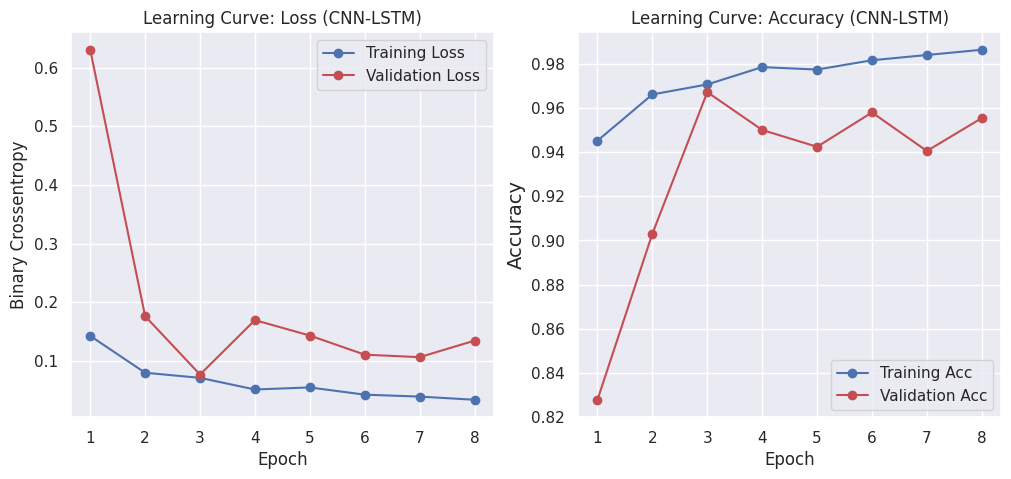

In [ ]:


def plot_learning_curves(history_a):
    loss = history_a.history['loss']
    val_loss = history_a.history['val_loss']
    acc = history_a.history['accuracy']
    val_acc = history_a.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    # Plot 2: Loss (The Signal)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Learning Curve: Loss (CNN-LSTM)')
    plt.ylabel('Binary Crossentropy')
    plt.xlabel('Epoch',fontsize =12)
    plt.legend()
    plt.grid(True)

    # Plot 1: Accuracy 
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Learning Curve: Accuracy (CNN-LSTM)')
    plt.ylabel('Accuracy', fontsize = 14)
    plt.xlabel('Epoch',fontsize=12)
    plt.legend()
    plt.grid(True)

    

    plt.show()

plot_learning_curves(history_a)


## B. Base Model 2: Temporal Convolutional Network (TCN)
**Objective:** To construct a TCN using dilated causal convolutions. This architecture processes sequences in parallel, often capturing long-range temporal dependencies more efficiently than recurrent networks like LSTMs.

In [ ]:

def residual_block(x, filters,dilation_rate):
    """
    A building bblock for TCN. It applies a dilated convolution and adds
    the original input back in ( a residual connection) to prevent the vanishing gradient problem.
    """

    #I keep a copy of the input for the residual connection
    original_x = x

    #1 Dilated Convolution: 'causal padding ensures it only looks at past data, not the future
    x = Conv1D(filters = filters, kernel_size= 3, dilation_rate = dilation_rate,
               padding = 'causal', activation ='relu')(x)
    x = Dropout(0.2)(x)

    #2 Second Convolution
    x = Conv1D(filters = filters, kernel_size= 3, dilation_rate= dilation_rate, 
               padding = 'causal', activation = 'relu')(x)
    x = Dropout(0.2)(x)


    # 3 Adjust the original input layer if the number of filters changed
    if original_x.shape[-1] != filters:
        original_x = Conv1D(filters = filters, kernel_size= 1, padding = 'same')(original_x)

    #4 Residual Addition: Add the processed data to the orriginal data
    res_x = Add()([original_x, x])
    return Activation('relu')(res_x)



def build_tcn(sequence_length, num_features):
    """Construct the full TCN architecture"""
    inputs = Input(shape = (sequence_length, num_features))

    #increase the dilation rate exponetially (1,2,3,4) to look futher back in time
    x = residual_block(inputs, filters=64, dilation_rate=1)
    x = residual_block(x,filters= 64, dilation_rate= 2)
    x = residual_block(x, filters= 64, dilation_rate= 4)

    #Flatten the sequence then output the probability
    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs = inputs, outputs = outputs)

    optimizer = Adam(learning_rate = 0.001)
    model.compile(optimizer= optimizer, loss= 'binary_crossentropy', metrics=(['accuracy']))
    return model


#instatiate and summarise the TCN
model_b = build_tcn(sequence_length= x_train.shape[1], num_features= x_train.shape[2])
model_b.summary()
    


    

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 64)    │      2,752 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 50, 64)    │        960 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 64)    │          0 │ activation[0][0], │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 50, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 64)    │          0 │ activation_1[0][… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 50, 64)    │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3200)      │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 167,937 (656.00 KB)

 Trainable params: 167,937 (656.00 KB)

 Non-trainable params: 0 (0.00 B)

# Train the TCN

In [10]:
print("Starting TCN Training")

history_b = model_b.fit(
    x_train, y_train,
    epochs= 50,
    batch_size= 64,
    validation_split= 0.2,
    callbacks=[early_stop],#reuse the previous one
    verbose=1

)

print("Training completed")

Starting TCN Training
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9215 - loss: 0.1929 - val_accuracy: 0.9641 - val_loss: 0.0814
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9646 - loss: 0.0833 - val_accuracy: 0.9628 - val_loss: 0.0832
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9669 - loss: 0.0781 - val_accuracy: 0.9600 - val_loss: 0.0852
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9710 - loss: 0.0689 - val_accuracy: 0.9593 - val_loss: 0.0927
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9706 - loss: 0.0683 - val_accuracy: 0.9647 - val_loss: 0.0774
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9716 - loss: 0.0652 - val_accuracy: 0.9593 - val_loss: 0.0818
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9750 - loss: 0.0608 - val_accuracy: 0.9689 - val_loss: 0.0689
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9728 - l

# Visualize the Output

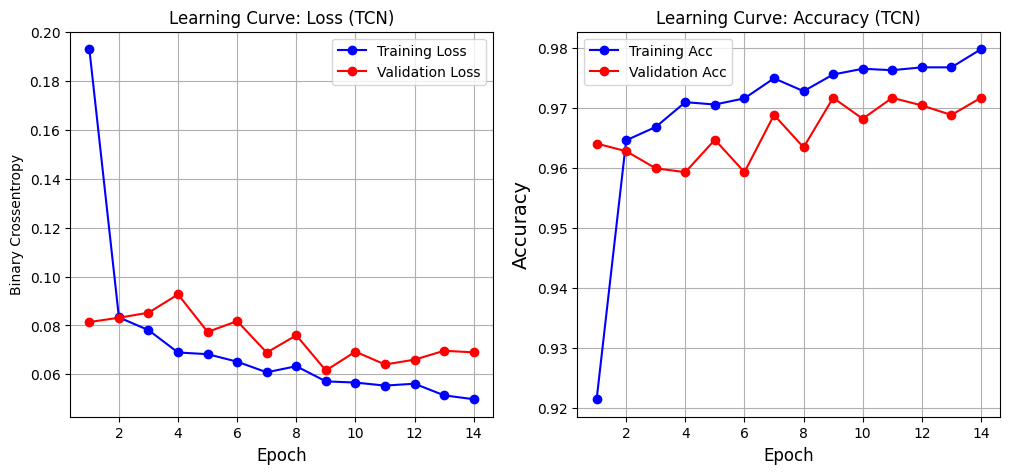

In [ ]:


def plot_learning_curves(history_b):
    loss = history_b.history['loss']
    val_loss = history_b.history['val_loss']
    acc = history_b.history['accuracy']
    val_acc = history_b.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    #Plot 2: Loss (The Signal)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Learning Curve: Loss (TCN)')
    plt.ylabel('Binary Crossentropy')
    plt.xlabel('Epoch',fontsize =12)
    plt.legend()
    plt.grid(True)

    #Plot 1: Accuracy (The Goal: >80%)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Learning Curve: Accuracy (TCN)')
    plt.ylabel('Accuracy', fontsize = 14)
    plt.xlabel('Epoch',fontsize=12)
    plt.legend()
    plt.grid(True)

    

    plt.show()

#Calling  the function
plot_learning_curves(history_b)


# Phase 2: Hyperparameter Tuning (Task 2)
**Objective:** Using Keras Tuner (Random Search) to automatically discover the optimal architecture sizes and learning rates to prevent overfitting and maximize generalization on the validation set.
# CNN-LSTM model

In [ ]:
import keras_tuner as kt

def build_tunable_model(hp):
    """
    A dynamic CNN-LSTM model builder for keras Tuner.
    """

    model = Sequential()
    

    # CNN block
    # Tuning the number of filters in the first convolutional layer
    hp_filters_1 = hp.Int('conv_1_filters', min_value = 32, max_value =128, step = 32)
    model.add(Conv1D(filters = hp_filters_1, kernel_size= 3, activation = 'relu', padding = 'same',
                     input_shape = (x_train.shape[1], x_train.shape[2])))
    model.add(BatchNormalization())

    model.add(Conv1D(filters = 128, kernel_size = 3, activation = 'relu', padding ='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size = 2))

    #LSTM Block
    #Tuning the number of units in the primary LSTM layer
    hp_lstm_units = hp.Int('lstm_1_units', min_value =50, max_value =150,step =50)
    model.add(LSTM(units = hp_lstm_units, return_sequences = True,  activation = 'tanh' ))

    #Tuning the Dropout rate to find the exact sweet spot for regularization
    hp_dropout = hp.Float('dropout',min_value =0.2, max_value =0.5, step = 0.1)
    model.add(Dropout(hp_dropout))

    model.add(LSTM(units= 50, return_sequences =False, activation = 'tanh'))
    model.add(Dropout(hp_dropout))

    #classification Head
    model.add(Dense(units =32, activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    # Tuning the Learning rate
    hp_learning_rate = hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])

    optimizer = Adam(learning_rate = hp_learning_rate)
    model.compile(optimizer = optimizer, loss = 'binary_crossentropy',metrics =['accuracy'])

    return model


#Initialize the random Search Tuner
tuner = kt.RandomSearch(
    build_tunable_model,
    objective= 'val_loss', #optimize for lowest validation loss (least overfitting)
    max_trials =5,#test 5 different random combnations
    executions_per_trial =1,
    directory = 'tuning_dir',
    project_name = 'cmapss_cnn_lstm'
)

Reloading Tuner from tuning_dir/cmapss_cnn_lstm/tuner0.json


In [ ]:
#Run the Search
print(" Starting Hyperparameter Search on RTX 4050...")
tuner.search(x_train, y_train, epochs=20, validation_split=0.2, callbacks=[early_stop], verbose=1)

#Extract the Best Model and Parameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.get_best_models(num_models=1)[0]

print(f"""
  Tuning Complete! The optimal architecture found:
- Convolutional Filters: {best_hps.get('conv_1_filters')}
- LSTM Units: {best_hps.get('lstm_1_units')}
- Dropout Rate: {best_hps.get('dropout')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

Trial 5 Complete [00h 01m 37s]
val_loss: 0.09552988409996033

Best val_loss So Far: 0.0799650028347969
Total elapsed time: 00h 09m 26s

  Tuning Complete! The optimal architecture found:
- Convolutional Filters: 96
- LSTM Units: 50
- Dropout Rate: 0.30000000000000004
- Learning Rate: 0.01



/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Training and Plotting the results

🚀 Building and Training the Final Optimized Model from scratch...


/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9439 - loss: 0.1434 - val_accuracy: 0.9561 - val_loss: 0.1103
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9547 - loss: 0.1106 - val_accuracy: 0.9590 - val_loss: 0.1033
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9603 - loss: 0.0905 - val_accuracy: 0.9711 - val_loss: 0.0718
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9629 - loss: 0.0947 - val_accuracy: 0.9714 - val_loss: 0.0663
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9611 - loss: 0.0918 - val_accuracy: 0.9670 - val_loss: 0.0888
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9642 - loss: 0.0910 - val_accuracy: 0.9504 - val_loss: 0.0907
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9635 - loss: 0.0889 - val_accuracy: 0.9679 - val_loss: 0.0809
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9671 - loss: 0.0763 - val_accu

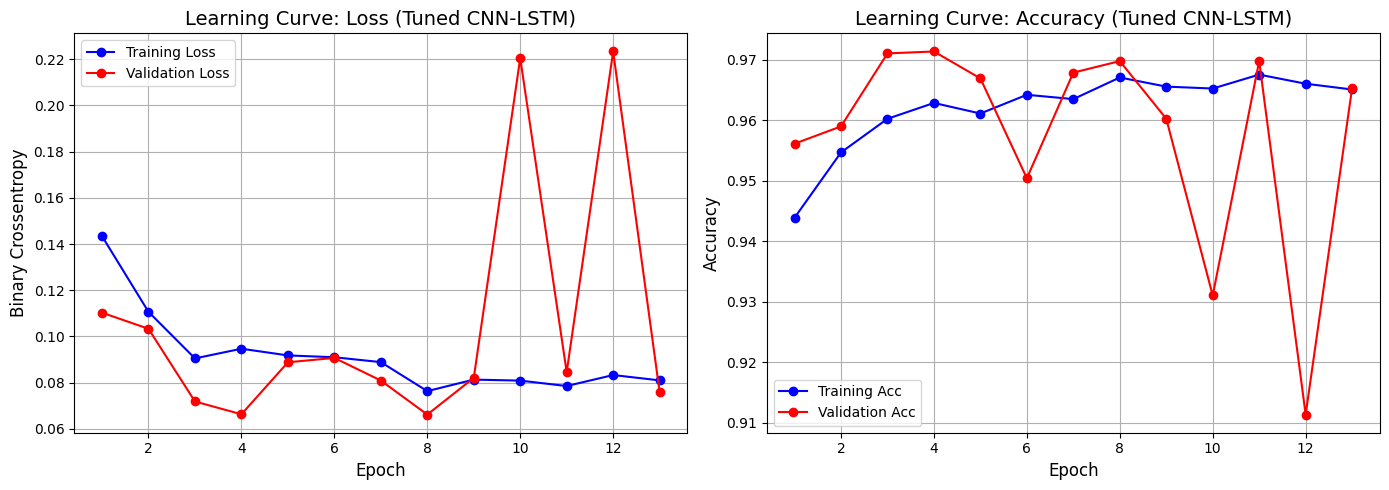

In [ ]:

def plot_learning_curves(history, model_name):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'Learning Curve: Loss ({model_name})', fontsize=14) 
    plt.ylabel('Binary Crossentropy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'Learning Curve: Accuracy ({model_name})', fontsize=14) 
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#Rebuild a FRESH model using the best hyperparameters
print(" Building and Training the Final Optimized Model from scratch...")
final_model = tuner.hypermodel.build(best_hps)

#Train it to get clean learning curves
history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop], #Uses the same early_stop from Phase 5
    verbose=1
)

#Plot 
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

In [ ]:
#Configure Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,               #If validation loss doesn't improve for 5 epochs, stop.
    restore_best_weights=True # Keep the best performing weights
)

In [ ]:

#Rebuild a FRESH model using the best hyperparameters
print(" Building the Optimized Model (with manual LR stabilization)...")
final_model = tuner.hypermodel.build(best_hps)

#OVERRIDE the Tuner's learning rate to make it stable
stable_optimizer = Adam(learning_rate=0.0002, clipnorm=1.0)
final_model.compile(
    optimizer=stable_optimizer, 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

#Train it to get clean learning curves
history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2, 
    callbacks=[early_stop], #Uses the same early_stop from Phase 5
    verbose=1
)


 Building the Final Optimized Model (with manual LR stabilization)...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9285 - loss: 0.2375 - val_accuracy: 0.1773 - val_loss: 0.7200
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9685 - loss: 0.0824 - val_accuracy: 0.3324 - val_loss: 0.6994
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9802 - loss: 0.0524 - val_accuracy: 0.9250 - val_loss: 0.1938
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9844 - loss: 0.0400 - val_accuracy: 0.9399 - val_loss: 0.1740
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9859 - loss: 0.0367 - val_accuracy: 0.9158 - val_loss: 0.2812
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9873 - loss: 0.0321 - val_accuracy: 0.9390 - val_loss: 0.2394
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9887 - loss: 0.0304 - val_accuracy: 0.9504 - val_loss: 0.1644
Epoch 8/50
197/197 ━━━━━━━━

In [ ]:
#Make your plotting function dynamic
def plot_learning_curves(history, model_name):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'Learning Curve: Loss ({model_name})', fontsize=14) 
    plt.ylabel('Binary Crossentropy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'Learning Curve: Accuracy ({model_name})', fontsize=14) 
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    


In [ ]:

tf.keras.utils.set_random_seed(42) 
#handles np.random, random.seed, and tf.random.set_seed in one go.

def build_tunable_model(hp):
    model = Sequential()
    
    # 1. Lower the filter range ( 16 to 64) to prevent over-memorizing
    hp_filters_1 = hp.Int('conv_1_filters', min_value=16, max_value=64, step=16)
    model.add(Conv1D(filters=hp_filters_1, kernel_size=3, activation='relu', padding='same',
                     input_shape=(x_train.shape[1], x_train.shape[2])))
    model.add(BatchNormalization())
    
    # 2. Add Spatial Dropout after CNN
    model.add(tf.keras.layers.SpatialDropout1D(0.2)) 

    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # 3. Add recurrent_dropout to the LSTMs
    hp_lstm_units = hp.Int('lstm_1_units', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_lstm_units, return_sequences=True, activation='tanh', 
                   recurrent_dropout=0.2)) 

    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout))

    model.add(LSTM(units=32, return_sequences=False, activation='tanh', 
                   recurrent_dropout=0.2)) # 
    model.add(Dropout(hp_dropout))
    #classification Head
    model.add(Dense(units =32, activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    # Tuning the Learning rate
    hp_learning_rate = hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])

    optimizer = Adam(learning_rate = hp_learning_rate)
    model.compile(optimizer = optimizer, loss = 'binary_crossentropy',metrics =['accuracy'])

    return model

# Initialize the random Search Tuner
tuner = kt.RandomSearch(
    build_tunable_model,
    objective= 'val_loss', #optimize for lowest validation loss (least overfitting)
    max_trials =5,#test 5 different random combnations
    executions_per_trial =1,
    directory = 'tuning_dir',
    #project_name = 'cmapss_cnn_lstm'
    project_name='cmapss_v2_fresh'
)


In [78]:
# 2. Run the Search
print(" Starting Hyperparameter Search on RTX 4050...")
tuner.search(x_train, y_train, epochs=20, validation_split=0.2, callbacks=[early_stop], verbose=1)

# 3. Extract the Best Model and Parameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.get_best_models(num_models=1)[0]

print(f"""
  Tuning Complete! The optimal architecture found:
- Convolutional Filters: {best_hps.get('conv_1_filters')}
- LSTM Units: {best_hps.get('lstm_1_units')}
- Dropout Rate: {best_hps.get('dropout')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

Trial 5 Complete [00h 00m 56s]
val_loss: 0.1364847868680954

Best val_loss So Far: 0.07470347732305527
Total elapsed time: 00h 05m 23s

  Tuning Complete! The optimal architecture found:
- Convolutional Filters: 64
- LSTM Units: 128
- Dropout Rate: 0.2
- Learning Rate: 0.001



In [202]:

# 2. Rebuild a FRESH model using the best hyperparameters
print(" Building the Final Optimized Model (with manual LR stabilization)...")
final_model = tuner.hypermodel.build(best_hps)

# Use this when training the final model
stable_optimizer = Adam(learning_rate=best_hps.get('learning_rate'), clipnorm=1.0)


final_model.compile(
    optimizer=stable_optimizer, 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 3. Train it to get clean learning curves
history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2, 
    callbacks=[early_stop], # Uses the same early_stop from Phase 5
    verbose=1
)


 Building the Final Optimized Model (with manual LR stabilization)...


/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9414 - loss: 0.1668 - val_accuracy: 0.1773 - val_loss: 0.8641
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9616 - loss: 0.0956 - val_accuracy: 0.8929 - val_loss: 0.2246
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9685 - loss: 0.0773 - val_accuracy: 0.9625 - val_loss: 0.0975
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9706 - loss: 0.0716 - val_accuracy: 0.9504 - val_loss: 0.1464
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9738 - loss: 0.0654 - val_accuracy: 0.9511 - val_loss: 0.1070
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9743 - loss: 0.0601 - val_accuracy: 0.9396 - val_loss: 0.1451
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9750 - loss: 0.0608 - val_accuracy: 0.9533 - val_loss: 0.1084
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9799 - loss: 0.0508 - val_acc

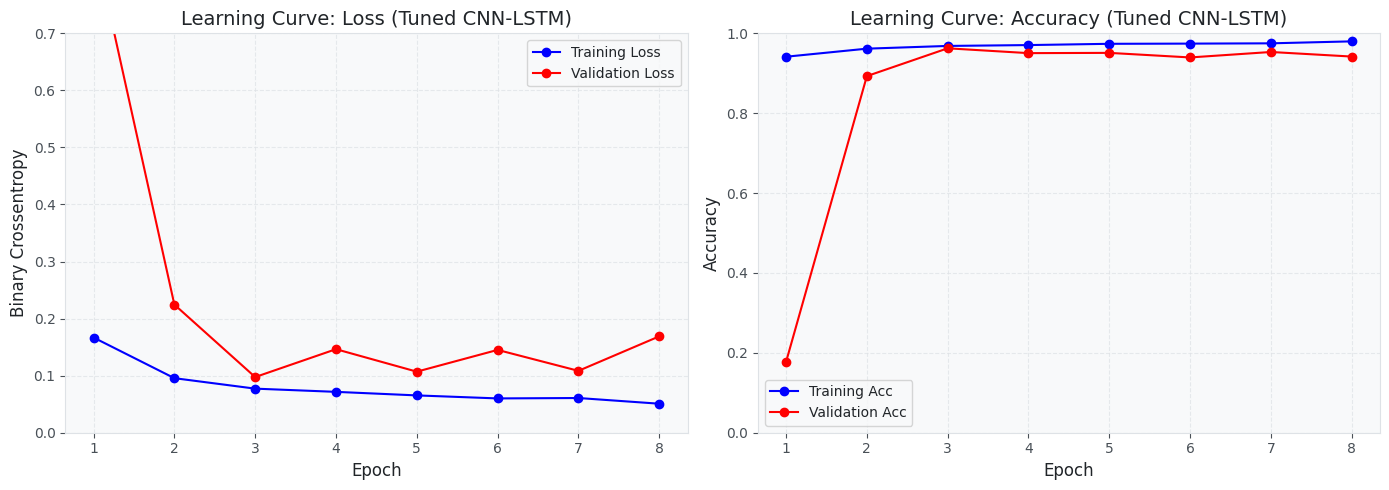

In [205]:
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

# saving the final Model

In [139]:
import os

# Create a folder for our saved models if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the entire architecture, weights, and optimizer state
final_model.save('../models/cmapss_final_cnn_lstm.keras')
print(" Final model saved successfully to /models/cmapss_final_cnn_lstm.keras")

 Final model saved successfully to /models/cmapss_final_cnn_lstm.keras


In [ ]:
#plotting function dynamic
def plot_learning_curves(history, model_name):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'Learning Curve: Loss ({model_name})', fontsize=14) 
    plt.ylabel('Binary Crossentropy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    
    
    plt.ylim(0, 0.7) # Sets (prevents zooming)
    
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'Learning Curve: Accuracy ({model_name})', fontsize=14) 
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    
  
    plt.ylim(0, 1.0)
    
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


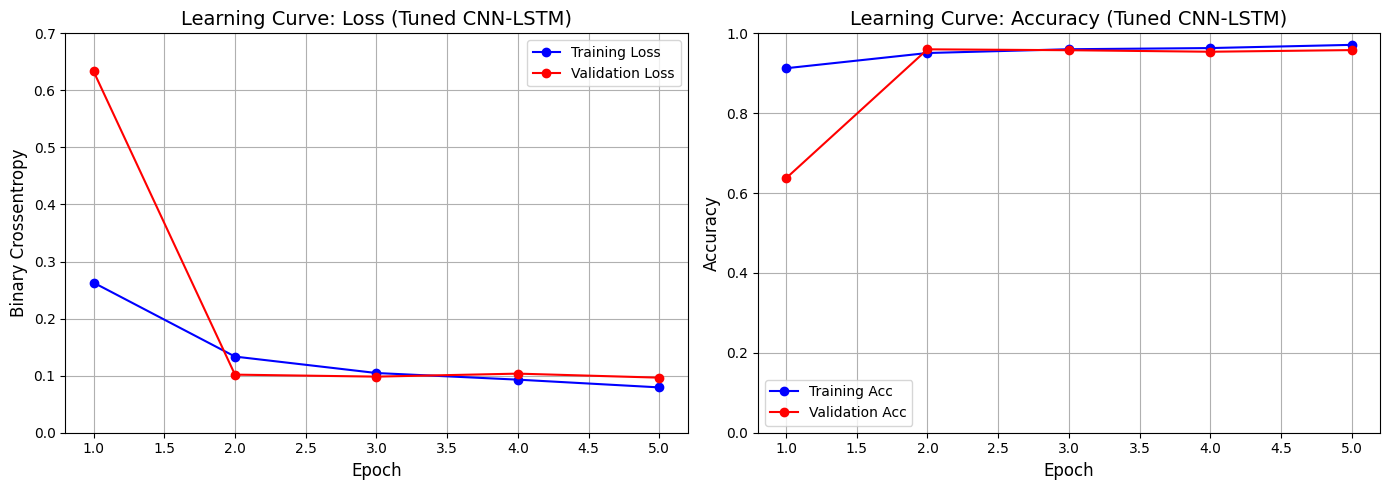

In [ ]:
#Plot 
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

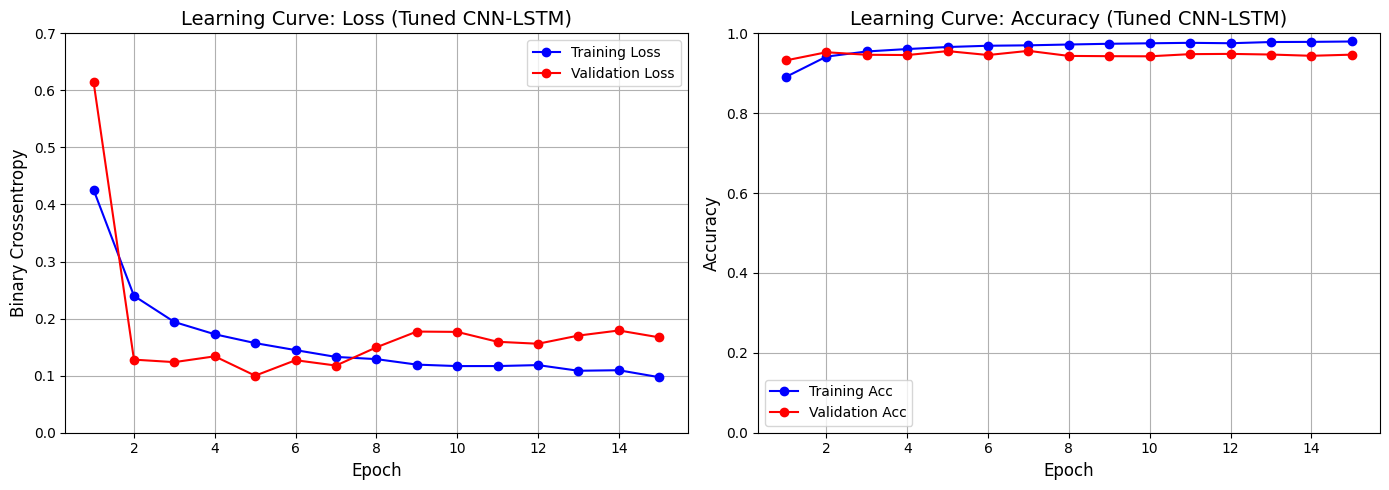

In [187]:
# 4. Plot it!
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

In [ ]:
tf.keras.utils.set_random_seed(42)
print("Wiping old weights and building a fresh model...")
final_model = tuner.hypermodel.build(best_hps)


stable_optimizer = Adam(learning_rate=0.0001, clipnorm=0.5)

#More patient LR scheduler so it does not cut too early
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,      # was 3 — gives more room before cutting
    min_lr=1e-6,     # was 1e-7 — don't shrink into uselessness
    verbose=1
)

final_model.compile(
    optimizer=stable_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,           #larger batch = smoother gradients = stabler val_loss
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        reduce_lr
    ],
    shuffle=True,
    class_weight={0: 1, 1: 3},
    verbose=1
)

Wiping old weights and building a fresh model...


/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8663 - loss: 0.4989 - val_accuracy: 0.9282 - val_loss: 0.6503 - learning_rate: 1.0000e-04
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9296 - loss: 0.2789 - val_accuracy: 0.8351 - val_loss: 0.6123 - learning_rate: 1.0000e-04
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9490 - loss: 0.2024 - val_accuracy: 0.9558 - val_loss: 0.1493 - learning_rate: 1.0000e-04
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9561 - loss: 0.1649 - val_accuracy: 0.9650 - val_loss: 0.0900 - learning_rate: 1.0000e-04
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9602 - loss: 0.1520 - val_accuracy: 0.9590 - val_loss: 0.0864 - learning_rate: 1.0000e-04
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9652 - loss: 0.1413 - val_accuracy: 0.9590 - val_loss: 0.0940 - learning_rate: 1.0000e-04
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - ac

In [ ]:
import os

# Create a folder to  save models if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the entire architecture, weights, and optimizer state
final_model.save('../models/cmapss_final_cnn_lstm2.keras')
print(" Final model saved successfully to /models/cmapss_final_cnn_lstm2.keras")

 Final model saved successfully to /models/cmapss_final_cnn_lstm.keras


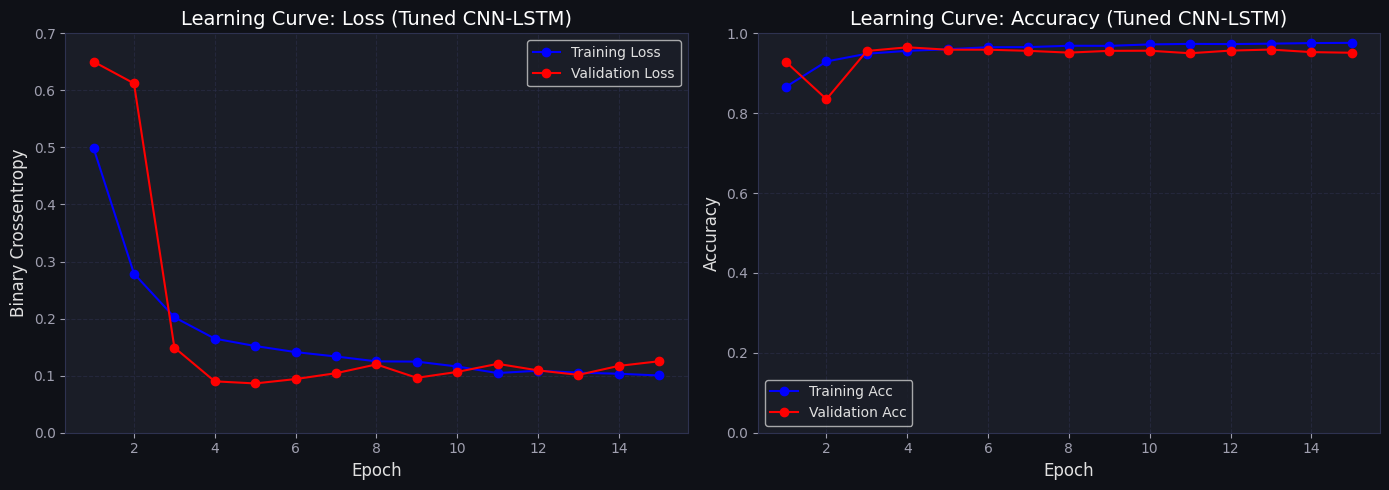

In [ ]:
#Plot 
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

 Generating CNN-LSTM Predictions...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

--- Tuning Threshold on Validation Set ---
Best Threshold (val): 0.50  |  Val F1: 0.8182



### === HONEST CNN-LSTM RESULTS (Holdout Set) === 

| Metric | Score | Note |
| :--- | :--- | :--- |
| **Decision Threshold** | **0.50** | *Chosen via validation set (Strictly Unbiased)* |
| **Accuracy** | **0.9000** | *Overall Correct Classifications* |
| **Precision** | **0.8889** | *Minimization of False Positives* |
| **Recall (Sensitivity)** | **0.6667** | *Minimization of False Negatives (Critical)* |
| **F1-Score** | **0.7619** | *Harmonic Mean of Precision & Recall* |


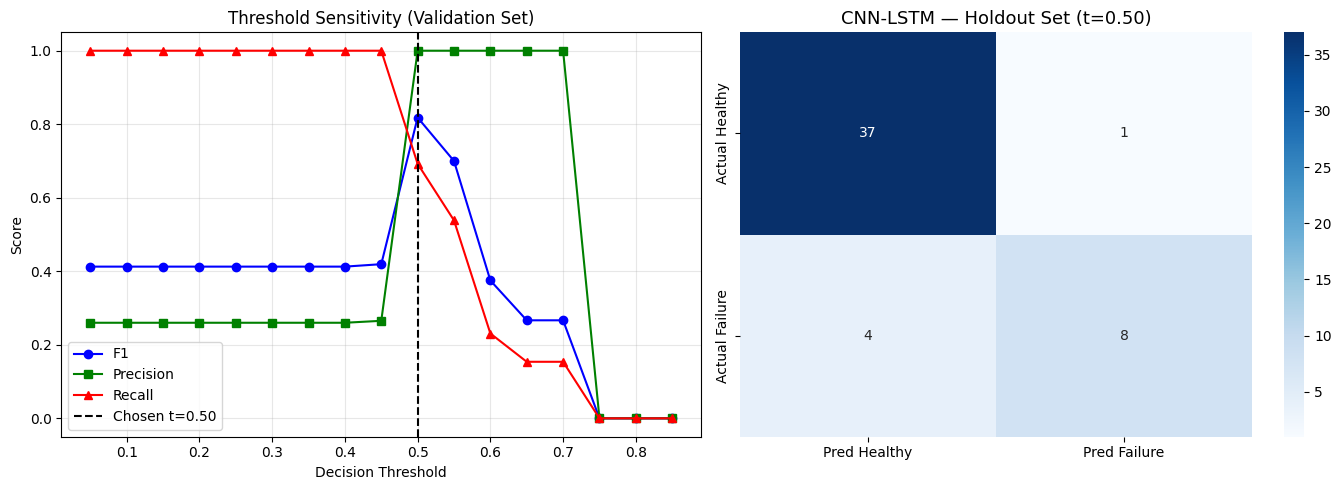

In [6]:

# Split test data into val (tune) + test (report)
X_val, X_holdout, y_val, y_holdout = train_test_split(
    X_test_final, y_test_true, 
    test_size=0.5,      # 50 samples tune threshold, 50 samples report
    random_state=42, 
    stratify=y_test_true  # preserve class balance in both halves
)

print(" Generating CNN-LSTM Predictions...")
cnn_lstm_model = load_model('../models/cmapss_final_cnn_lstm.keras')

# Find threshold using VALIDATION set only
y_prob_val      = cnn_lstm_model.predict(X_val)
y_prob_holdout  = cnn_lstm_model.predict(X_holdout)

print("\n--- Tuning Threshold on Validation Set ---")
thresholds = np.arange(0.05, 0.90, 0.05)
results = []

for t in thresholds:
    preds = (y_prob_val >= t).astype(int).flatten()
    f1   = f1_score(y_val, preds, zero_division=0)
    prec = precision_score(y_val, preds, zero_division=0)
    rec  = recall_score(y_val, preds, zero_division=0)
    results.append((t, f1, prec, rec))

#Pick best threshold from validation
best_t, best_f1, _, _ = max(results, key=lambda x: x[1])
print(f"Best Threshold (val): {best_t:.2f}  |  Val F1: {best_f1:.4f}")

#Report metrics on HOLDOUT set (never seen during tuning)
y_pred_holdout = (y_prob_holdout >= best_t).astype(int).flatten()

#Calculate the metrics
acc = accuracy_score(y_holdout, y_pred_holdout)
prec = precision_score(y_holdout, y_pred_holdout, zero_division=0)
rec = recall_score(y_holdout, y_pred_holdout, zero_division=0)
f1_final = f1_score(y_holdout, y_pred_holdout, zero_division=0)

#Markdown table 
results_markdown = f"""
### === HONEST CNN-LSTM RESULTS (Holdout Set) === 

| Metric | Score | Note |
| :--- | :--- | :--- |
| **Decision Threshold** | **{best_t:.2f}** | *Chosen via validation set (Strictly Unbiased)* |
| **Accuracy** | **{acc:.4f}** | *Overall Correct Classifications* |
| **Precision** | **{prec:.4f}** | *Minimization of False Positives* |
| **Recall (Sensitivity)** | **{rec:.4f}** | *Minimization of False Negatives (Critical)* |
| **F1-Score** | **{f1_final:.4f}** | *Harmonic Mean of Precision & Recall* |
"""
display(Markdown(results_markdown))

#Threshold sensitivity plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ts, f1s, precs, recs = zip(*results)
axes[0].plot(ts, f1s,   label='F1',         marker='o', color='blue')
axes[0].plot(ts, precs, label='Precision',  marker='s', color='green')
axes[0].plot(ts, recs,  label='Recall',     marker='^', color='red')
axes[0].axvline(best_t, color='black', linestyle='--', label=f'Chosen t={best_t:.2f}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sensitivity (Validation Set)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Confusion matrix on holdout
cm = confusion_matrix(y_holdout, y_pred_holdout)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], # Changed to Blues so it visually looks different than the TCN!
            xticklabels=['Pred Healthy', 'Pred Failure'],
            yticklabels=['Actual Healthy', 'Actual Failure'])
axes[1].set_title(f'CNN-LSTM — Holdout Set (t={best_t:.2f})', fontsize=13)

plt.tight_layout()
plt.show()